#### Name: Sutton Ursillo

# PHYS 230 Lab Assignment 17

### Wednesday, April 8, 2026: Chapter 10.1
- Random numbers

In [1]:
# import statements here
import matplotlib.pyplot as plt
import numpy as np
import random

## Part 1: Testing random number generators

#### Step 1: Write a function `LCM_random(a,c,m,N,x)` that generates a list of $N$ random numbers using the linear congruent method from a starting seed $x$. 

In [32]:
def LCM_random(a,c,m,N,x):
    #empty list
    vals = []
    
    #congruent method
    for i in range(N):
        x = (a*x+c) % m
        vals.append(x)
    return vals



#### Step 2: Call on your function from step 1 using the most accepted values of the constants $a,c$, and $m$, and whatever you want to use as the seed. Create an array $r$ of 1000 points. Repeat testing at least three different seeds total. 

In [34]:
    #constants
    a = 1664525
    c = 1013904226
    m = 4294967296

    #seed
    x1 = 21
    x2 = 2020202
    x3 = 987654321

    #steps
    N =1000

    r1 = np.array(LCM_random(a,c,m,N,x1))
    r2 = np.array(LCM_random(a,c,m,N,x2))
    r3 = np.array(LCM_random(a,c,m,N,x3))
    print(r1,r2,r3)


[1048859251  792458553 2025856327 3318331901 3514643259 3270971233
  328491343 3665059429 3922787459  158529545 3204063703 3869070669
 4142790219 2751026993 1822353119 2621736629 2705516691 3420083417
 3716462695 1605655197 3456572251  865376513   17440367 1256831237
  998397603 2793229225    7479543 4084992493 4258587243  250090705
 2129414143 3674551637 2755626675  181345401  370973575 4060717885
 1324059515 3069905569 2535695247  358628261 2100476099 3635087177
  405170199 3994707597 3697759883  230472305 1448505631  468454389
 3743165651  726944793 1954137767  303272925 1693221787 1929667649
 2649944239 2395072069  985932515 3329633001 2521364279  352480045
 3148305067 2173782033 3173999167 1361250965 1509612275  589554617
 2400074183 3483118717 1498153915 1812637153  705299919 4000889061
 2157483267  483964553 3750481495 1899894733  219600587 4194287025
 1514740575 2673094965 2910687507 1048044377 1623979239 1424846109
 3452701659  619171713 3162170095 4000232325 4220653347 294103

#### Step 3: Make a plot (or separate plots may be best) of your arrays using Matplotlib Pyplot (simply feed in a single 1D array) to see how random the data truly is. In a markdown cell, explain any differences you notice when you use different seed values. 

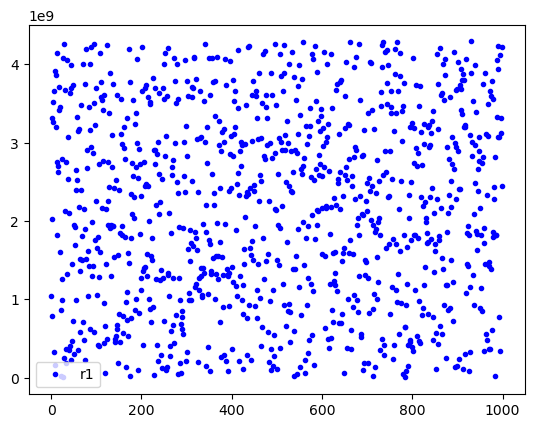

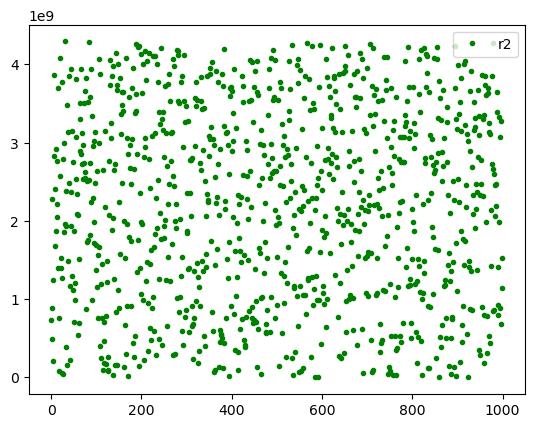

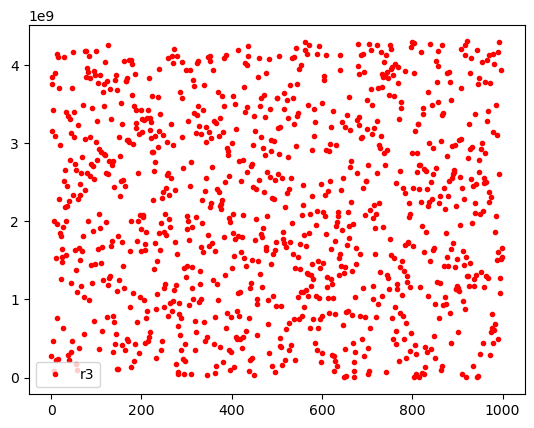

In [13]:
plt.plot(r1, ".b", label = "r1")
plt.legend()
plt.show()

plt.plot(r2, ".g", label= "r2")
plt.legend()
plt.show()

plt.plot(r3, ".r", label= "r3")
plt.legend()
plt.show()

Since these numbers are random the graphs are different but you have to look hard at them to really see the difference. They are all scaled the same so there are some close similarities but they are all different. 

#### Step 4: Make a plot of successive random numbers for one of your arrays, where your plot points should be ($x,y$) = ($r_i$, $r_{i+1}$). What do you notice about this plot? Do the values truly seem random? 

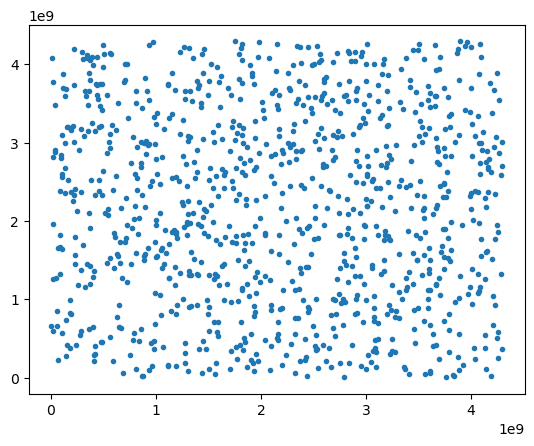

In [35]:

x = r1[:-1]
y = r1[1:]

plt.plot(x,y, '.')


yes these values do seem random, they are not the same as the r1 plot above.

#### Step 5: Now try an unwise choice of constant for the linear congruent method. Try using $(a,c,m,x) = (57,1,256,10)$ to generate 1000 random values. Make a 1D plot and also the plot (x,y) = ($r_i$, $r_{i+1}$). Explain what you notice about these plots compared to above. 

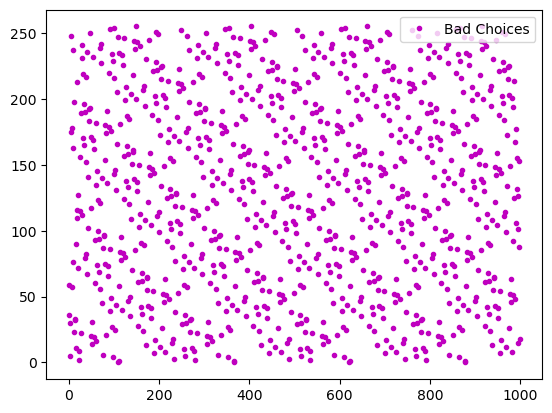

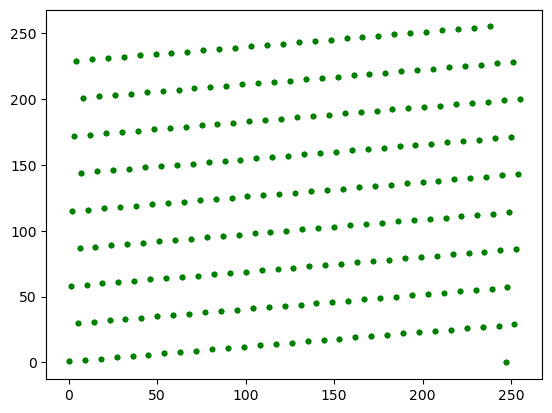

In [36]:
a = 57
c = 1
m = 256
x = 10
N = 1000

r_bad = LCM_random(a,c,m,N,x)
plt.plot(r_bad, ".m", label = "Bad Choices")
plt.legend()
plt.show()

x = r_bad[:-1]
y = r_bad[1:]

plt.plot(x,y, ".g")
plt.show()



These plots are not random, they have a clear pattern unlike the ones above that were truely random. The top one is 'random' in some spots but it just repeats itself as we go through more points.

#### Step 6: Use a built-in random number generator from the `random` package to create an array of 1000 points. Plot the results and compare as done in steps 3 and 4 above. (Don't forget to include a markdown with your comparison.) 

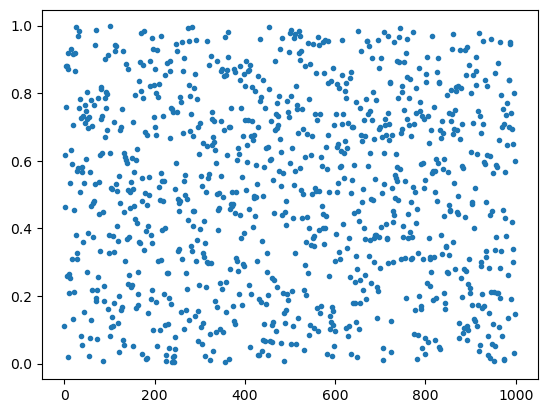

In [ ]:
N = 1000
r = []

for i in range(N):
    r.append(random.random())

plt.plot(r, '.')


It looks similar to the graphs we got above. It is truely random with no clear patterns.

## Part 2: Luck & Roulette 
(background information taken from [Wikipedia](https://en.wikipedia.org/wiki/Roulette))

Roulette is a casino game named after the French word meaning little wheel. In the game, a player may choose to place a bet on a single number, various groupings of numbers, the color red or black, whether the number is odd or even, or if the numbers are high (19–36) or low (1–18).

To determine the winning number, a croupier spins a wheel in one direction, then spins a ball in the opposite direction around a tilted circular track running around the outer edge of the wheel. The ball eventually loses momentum, passes through an area of deflectors, and falls onto the wheel and into one of  thirty-eight colored and numbered pockets on the wheel.

As explained above, there are many betting options for Roulette, seen on the roulette table layout below. One of the most common bets is either red or black. 

In this part of the lab, we're going to use a random number generator to determine the odds of winning when a gambling soul chooses red. 


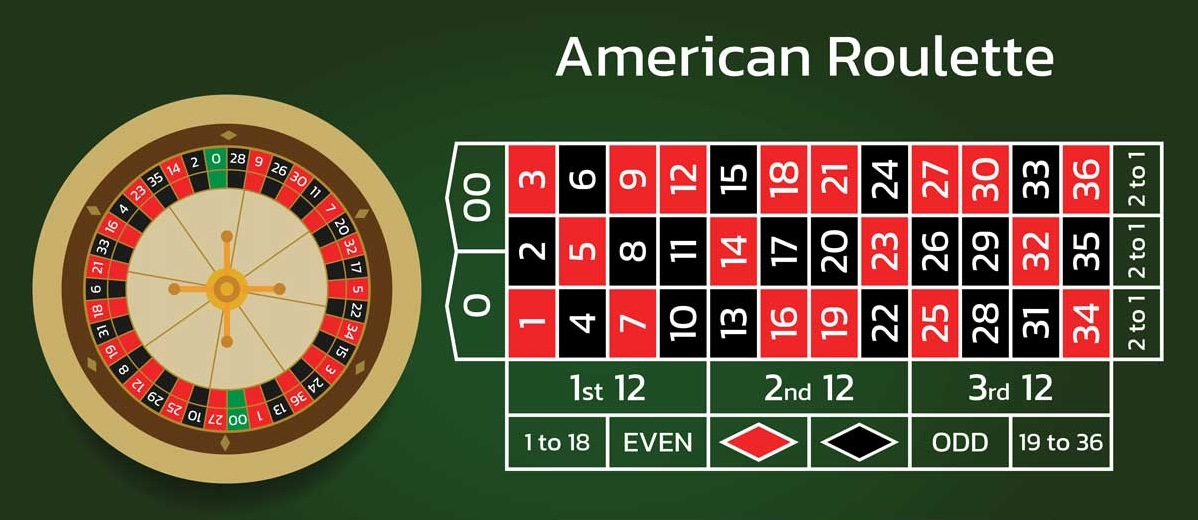

#### Step 1: Create two lists - `red` and `black` - which each contain all of the numbers that belong to those classifications. 

In [ ]:
red = [1,3,5,7,9,12,14,16,18,19,21,23,25,27,30,32,34,36]
black = [2,4,6,8,10,11,13,15,17,20,22,24,26,28,29,31,33,35]


#### Step 2: Develop a *function* to spin the roulette wheel $N$ times. 

In the code it should: 
- create three variables (red_count, black_count, green_count) initially set equal to 0 (Green count will be used to keep track of 0 & 00)
- select a random number between 1 and 38 (37 and 38 are being used to represent 0 and 00 for this game)
- check if that number is in red or black list (or neither) - this would be best done with if, elif, and else
- if the number is red, black, or neither, add one to the corresponding variable from step 2. 

In [57]:
def f(N):
    red_count = 0
    black_count = 0
    green_count = 0
    
    for i in range(N):
        number = random.randrange(38)
    
        if number in red:
            red_count += 1
        elif number in black:
            black_count += 1
        else:
            green_count += 1

    return red_count, black_count, green_count


r, b, g = f(1000)

print("red:", r)
print("black", b)
print("green", g)

    




red: 478
black 476
green 46


#### Step 3: Call on your function to spin the roulette wheel 100, 1000, and 10,000 times. 

For each completion, determine what percentage of the spins were indeed red. 

In [59]:
r, b, g = f(100)

print("100 Spins")
print("red:", r)
print("black", b)
print("green", g)


r, b, g = f(1000)

print("1000 Spins")
print("red:", r)
print("black", b)
print("green", g)

r, b, g = f(10000)

print("10000 Spins")
print("red:", r)
print("black", b)
print("green", g)

100 Spins
red: 48
black 49
green 3
1000 Spins
red: 484
black 467
green 49
10000 Spins
red: 4682
black 4759
green 559


#### Step 4: Vegas pays 1:1 for a red or black winning number, which would suggest you have a 50% chance of getting it right. Is this correct or is Vegas always putting the odds in their favor? Explain briefly. 

This is incorrect because of the green tiles. They act as a advantage for the house becuase there are now 3 options to pick from which makes the odd not 1:1. If we look at the percentages of the result say for the 100 spin test it was 48% red 49% black and 3% green. If we only bet on red we would have won 48% of the time and the house would have won 52% of the time so it is not a true 1:1. 